In [13]:
# Packages
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, coalesce, lit, expr, round
from pyspark.sql.functions import when
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Debug to run from time to time to check if there's a SparkSession running
from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is not None:
    print("A Spark session is running.")
else:
    print("No active Spark session.")

No active Spark session.


In [4]:
# Start sparksession
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
        .appName("MSDS Assignment 1")                
        .master("local[6]")                   
        .config("spark.driver.memory", "6g")  
        .config("spark.executor.memory", "4g")
        .config("spark.sql.shuffle.partitions", "12")
        .getOrCreate()
)

26/04/05 21:57:14 WARN Utils: Your hostname, Jonathans-MacBook-Pro-16.local resolves to a loopback address: 127.0.0.1; using 192.168.100.190 instead (on interface en0)
26/04/05 21:57:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/05 21:57:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
spark

In [6]:
df = spark.read.csv("../data/synthetic_mobile_money_transaction_dataset.csv", header=True, inferSchema=True)
df.show(5)

+----+---------------+--------+----------------+---------------+---------------+----------------+---------------+---------------+-------+
|step|transactionType|  amount|       initiator|oldBalInitiator|newBalInitiator|       recipient|oldBalRecipient|newBalRecipient|isFraud|
+----+---------------+--------+----------------+---------------+---------------+----------------+---------------+---------------+-------+
|   0|       TRANSFER|19824.96|4537027967639631|      187712.18|      167887.22|4875702729424478|           8.31|       19833.27|      1|
|   0|        PAYMENT|  598.97|4296267625767470|           8.92|           8.92|      25-0000401|            0.0|            0.0|      0|
|   0|        PAYMENT|  545.85|4178224023847746|           93.6|        -452.25|      13-0001587|            0.0|         545.85|      0|
|   0|       TRANSFER|19847.01|4178224023847746|        -452.25|      -20299.26|4096920916696293|        4011.72|       23858.74|      1|
|   0|        PAYMENT|  546.89|477

In [7]:
# Data Exploration
df.printSchema()
df.describe().show()

root
 |-- step: integer (nullable = true)
 |-- transactionType: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- initiator: long (nullable = true)
 |-- oldBalInitiator: double (nullable = true)
 |-- newBalInitiator: double (nullable = true)
 |-- recipient: string (nullable = true)
 |-- oldBalRecipient: double (nullable = true)
 |-- newBalRecipient: double (nullable = true)
 |-- isFraud: integer (nullable = true)



26/04/05 21:57:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 3:=================================================>         (5 + 1) / 6]

+-------+-----------------+---------------+-----------------+--------------------+------------------+------------------+--------------------+------------------+------------------+-------------------+
|summary|             step|transactionType|           amount|           initiator|   oldBalInitiator|   newBalInitiator|           recipient|   oldBalRecipient|   newBalRecipient|            isFraud|
+-------+-----------------+---------------+-----------------+--------------------+------------------+------------------+--------------------+------------------+------------------+-------------------+
|  count|          1720181|        1720181|          1720181|             1720181|           1720181|           1720181|             1720181|           1720181|           1720181|            1720181|
|   mean|65.55528633324052|           NULL|52538.67961220848|4.499951976758763...|2433757.5979887433| 2443879.729006279|4.501318368831969E15|108508.32875252634|122277.21539521578|0.10203461147402512|


In [8]:
df.count()

1720181

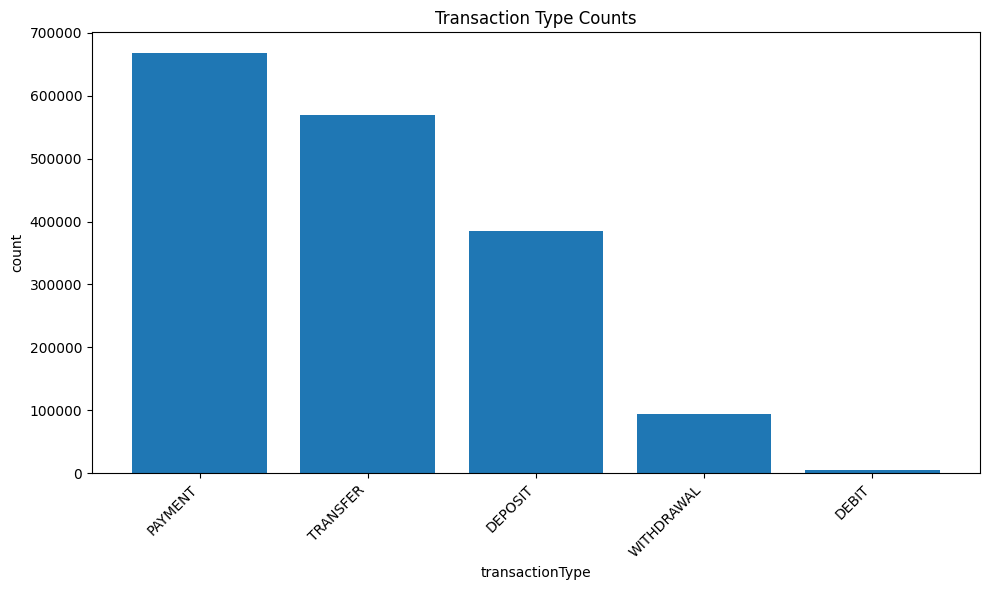

In [12]:
total = df.count()

value_counts = (
    df.groupBy("transactionType")
      .count()
      .withColumn("pct", round(col("count") / total, 4))
      .orderBy(col("count").desc())
)

pdf = value_counts.toPandas()
pdf = pdf.sort_values("count", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(pdf['transactionType'], pdf['count'], color='C0')
plt.xticks(rotation=45, ha='right')
plt.xlabel('transactionType')
plt.ylabel('count')
plt.title('Transaction Type Counts')
plt.tight_layout()
plt.show()


## Feature Engineering

In [9]:
# numerical_columns = ['amount', 'oldBalInitiator', 'newBalInitiator', 'oldBalRecipient', 'newBalRecipient']
# features_spark = df.select(*numerical_columns)

Since the ‘amount’ field seems to sometimes deviate from the difference between the Initiator and the new balances of one or both of the transaction parties, we decided to include these differences in the data as two additional features: ‘changebalanceInitiator’ and ‘changebalanceRecipient’.

In [ ]:
# features[‘changebalanceInitiator’] = features[‘newBalInitiator’] — features[‘oldBalInitiator’]
# features[‘changebalanceRecipient’] = features[‘newBalRecipient’] — features[‘oldBalRecipient’]

In [10]:
# features = df.select(
#     "amount",
#     "oldBalInitiator",
#     "newBalInitiator",
#     "oldBalRecipient",
#     "newBalRecipient"
# ).withColumn(
#     "changebalanceInitiator",
#     coalesce(col("newBalInitiator").cast("double"), lit(0.0)) - coalesce(col("oldBalInitiator").cast("double"), lit(0.0))
# ).withColumn(
#     "changebalanceRecipient",
#     coalesce(col("newBalRecipient").cast("double"), lit(0.0)) - coalesce(col("oldBalRecipient").cast("double"), lit(0.0))
# )

All numerical features can easily be used as inputs to the model, so the fields ‘amount’, ‘oldBalInitiator’, ‘newBalInitiator’, ‘oldBalRecipient’ and ‘newBalRecipient’ will be used as features as they are.

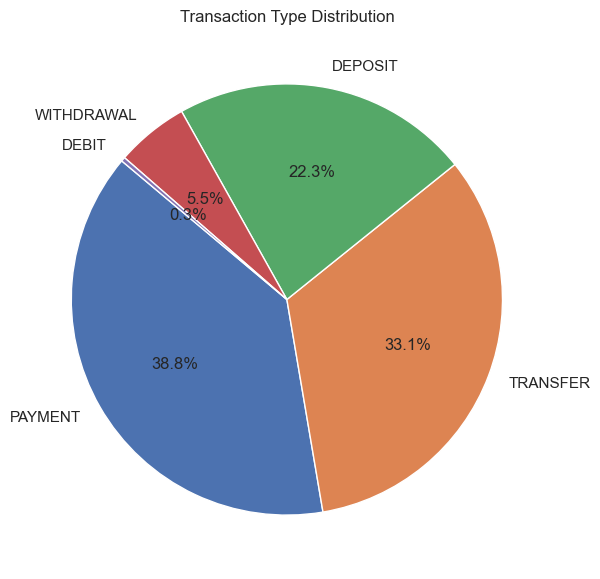

In [15]:
N = 8
top = pdf.head(N).copy()
others = pdf.iloc[N:]['count'].sum()
if others > 0:
    top = top.append({'transactionType':'Other', 'count':others, 'pct': others/total}, ignore_index=True)

# pie
plt.figure(figsize=(7,7))
plt.pie(top['count'], labels=top['transactionType'], autopct='%1.1f%%', startangle=140)
plt.title('Transaction Type Distribution')
plt.show()

Since the ‘step’ field gives us the relative timestamps of all transactions in an hourly resolution, we can derive the (hourly) time of the day when the transaction occurred. To do this we simply transform the ‘step’ field by applying the modulo of 24.

In [ ]:
# 1. Validate required columns
required = [
    "amount",
    "oldBalInitiator",
    "newBalInitiator",
    "oldBalRecipient",
    "newBalRecipient",
    "step",
    "transactionType"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# 2. Select numeric columns and cast to double (safe arithmetic)
numerical_columns = [
    "amount",
    "oldBalInitiator",
    "newBalInitiator",
    "oldBalRecipient",
    "newBalRecipient"
]

features = df.select(
    *[col(c).cast("double").alias(c) for c in numerical_columns],
    col("step"),
    col("type")
)

# 3. Compute changeBalInitiator and changeBalRecipient (handle nulls)
features = features.withColumn(
    "changeBalInitiator",
    coalesce(col("newBalInitiator"), lit(0.0)).cast("double")
    - coalesce(col("oldBalInitiator"), lit(0.0)).cast("double")
).withColumn(
    "changeBalRecipient",
    coalesce(col("newBalRecipient"), lit(0.0)).cast("double")
    - coalesce(col("oldBalRecipient"), lit(0.0)).cast("double")
)

# 4. Derive hour from step (hour of day, 0..23)
features = features.withColumn("hour", (col("step").cast("long") % 24).cast("int"))

# 5. One-hot encode `transactionType` into separate binary columns (explicit columns)
#    This creates one column per distinct value in `type`.
types = [row["transactionType"] for row in df.select("transactionType").distinct().collect()]
for t in types:
    safe_name = t.replace(" ", "_").replace("/", "_")  # simple sanitization
    features = features.withColumn(f"type_{safe_name}", when(col("type") == t, 1).otherwise(0))

# 6. Final feature set: drop original 'step' and 'type' if not needed
final_feature_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "changebalanceOrig",
    "changebalanceDest",
    "hour"
] + [f"type_{t.replace(' ', '_').replace('/', '_')}" for t in types]

features_spark = features.select(*final_feature_cols)